In [78]:
import pandas as pd 
import numpy 
import matplotlib.pyplot as plt 

In [79]:
df =pd.read_csv("spotify_top_songs_audio_features.csv")
df.head()

,id,artist_names,track_name,source,key,mode,time_signature,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,duration_ms,weeks_on_chart,streams
0,000xQL6tZNLJzIrtIgxqSl,"ZAYN, PARTYNEXTDOOR",Still Got Time (feat. PARTYNEXTDOOR),RCA Records Label,G,Major,4 beats,0.748,0.627,0.0639,0.13100,0.0,0.0852,0.524,-6.029,120.963,188491,17,107527761
1,003eoIwxETJujVWmNFMoZy,Alessia Cara,Growing Pains,Def Jam Recordings,C#/Db,Minor,4 beats,0.353,0.755,0.7330,0.08220,0.0,0.3900,0.437,-6.276,191.153,193680,2,9944865
2,003vvx7Niy0yvhvHt4a68B,The Killers,Mr. Brightside,Island Records,C#/Db,Major,4 beats,0.352,0.911,0.0747,0.00121,0.0,0.0995,0.236,-5.230,148.033,222973,125,512388123
3,00B7TZ0Xawar6NZ00JFomN,"Cardi B, Chance the Rapper",Best Life (feat. Chance The Rapper),Atlantic/KSR,A,Major,4 beats,0.620,0.625,0.5530,0.28700,0.0,0.3140,0.665,-7.438,167.911,284856,2,11985346
4,00Blm7zeNqgYLPtW6zg8cj,"Post Malone, The Weeknd",One Right Now (with The Weeknd),Republic Records,C#/Db,Major,4 beats,0.687,0.781,0.0530,0.03610,0.0,0.0755,0.688,-4.806,97.014,193507,30,301860377


In [80]:
median_weeks = df['weeks_on_chart'].median()
df['hit'] = (df['weeks_on_chart']>=median_weeks).astype(int)



In [81]:
numeric_cols = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence",
    "loudness", "tempo", "duration_ms"
]

categorical_cols = ["key", "mode", "time_signature"]


In [82]:
X = df[numeric_cols + ['key', 'mode', 'time_signature']]
y = df['hit']

In [83]:
from sklearn.model_selection import train_test_split ,GridSearchCV,StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler ,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

In [84]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=11,stratify=y)

preprocessor = ColumnTransformer([
    ('num',StandardScaler(),numeric_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
])

In [85]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}

cv = StratifiedKFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

gs_lr =GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring = 'accuracy',
    n_jobs=-1
)


gs_lr.fit(X_train,y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'classifier__C': [0.01, 0.1, ...], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [86]:
rf_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', RandomForestClassifier(random_state=11))
])


rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}
gs_rf = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv= cv,
    scoring = 'accuracy',
    n_jobs = -1
)

gs_rf.fit(X_train,y_train)



,estimator,Pipeline(step...m_state=11))])
,param_grid,"{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


training accuracy

In [87]:
lr_train_acc = accuracy_score(
    y_train , gs_lr.predict(X_train)
)
rf_train_acc = accuracy_score(
    y_train,
    gs_rf.predict(X_train)
)

test accuracy 

In [88]:
lr_test_acc = accuracy_score(
    y_test,
    gs_lr.predict(X_test)
)

rf_test_acc = accuracy_score(
    y_test,
    gs_rf.predict(X_test)
)

In [89]:

print("Best LR Params :", gs_lr.best_params_)
print("Best RF Params :", gs_rf.best_params_)


Best LR Params : {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best RF Params : {'classifier__max_depth': 10, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


In [90]:
print("\nLogistic Regression")
print("Train Accuracy :", round(lr_train_acc,4))
print("Test Accuracy  :", round(lr_test_acc,4))





Logistic Regression
Train Accuracy : 0.5912
Test Accuracy  : 0.5549


In [91]:
print("\nRandom Forest")
print("Train Accuracy :", round(rf_train_acc,4))
print("Test Accuracy  :", round(rf_test_acc,4))


Random Forest
Train Accuracy : 0.839
Test Accuracy  : 0.5948


In [92]:
from xgboost import XGBClassifier

In [93]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])

xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

In [94]:
gs_xgb = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

gs_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,"Pipeline(step...te=42, ...))])"
,param_grid,"{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [100, 200, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [95]:
xgb_train_acc = accuracy_score(
    y_train,
    gs_xgb.predict(X_train)
)

xgb_test_acc = accuracy_score(
    y_test,
    gs_xgb.predict(X_test)
)

print("Best XGBoost Params:", gs_xgb.best_params_)
print("Training Accuracy :", round(xgb_train_acc, 4))
print("Testing Accuracy  :", round(xgb_test_acc, 4))

Best XGBoost Params: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Training Accuracy : 0.7263
Testing Accuracy  : 0.5748


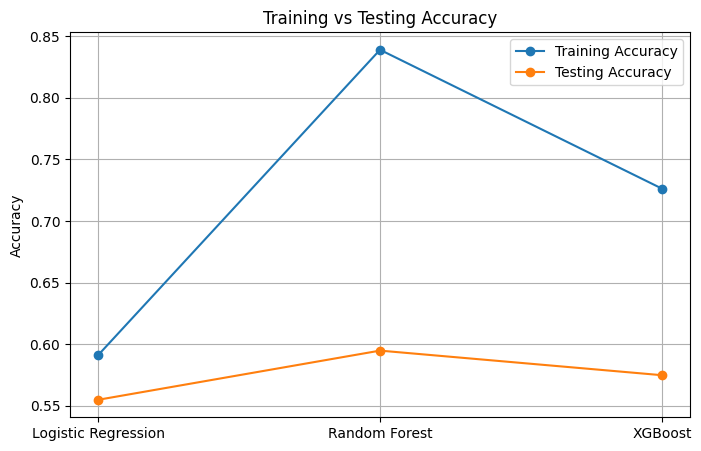

In [96]:
plt.figure(figsize=(8,5))

plt.plot(
    ["Logistic Regression", "Random Forest", "XGBoost"],
    [lr_train_acc, rf_train_acc, xgb_train_acc],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    ["Logistic Regression", "Random Forest", "XGBoost"],
    [lr_test_acc, rf_test_acc, xgb_test_acc],
    marker='o',
    label='Testing Accuracy'
)

plt.title("Training vs Testing Accuracy")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [97]:
import pickle 

with open ("best_model.pkl","wb") as f:
    pickle.dump(gs_rf.best_estimator_,f)


print("best model saved")


best model saved


In [99]:
best_rf = gs_rf.best_estimator_

rf = best_rf.named_steps['classifier']

importances = rf.feature_importances_

feature_names = (
    numeric_cols +
    list(
        best_rf.named_steps['preprocessor']
        .named_transformers_['cat']
        .get_feature_names_out(categorical_cols)
    )
)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(importance_df.head(15))

             Feature  Importance
2        speechiness    0.116405
6            valence    0.104147
7           loudness    0.102020
9        duration_ms    0.096465
0       danceability    0.094602
8              tempo    0.092321
5           liveness    0.084258
3       acousticness    0.080441
1             energy    0.077431
4   instrumentalness    0.050010
22        mode_Major    0.007880
23        mode_Minor    0.007746
14         key_C#/Db    0.007314
12             key_B    0.006944
20             key_G    0.006682
